In [26]:
# Time Series Forecasting
## ARIMA - Auto Regressive Integrated Moving Average
### Durbin watson value should be either less than 1.5 or more than 2.5
### There must be date and time column
### Date column should be in sequence order
### There should not be any missing data - imputation method
### check whether we have trend, seasonality, cyclical and random noise - decomposition method
### Time Series Forecasting value should be numeric and atleast 2 column (one datetime and 2nd prediction)
### Time Series Forecasting predicted value should be "Stationary" - Augmented Dickey Fuller Test or Rolling method

# Import the required libraries

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from pandas import Series
from numpy import log

In [29]:
df = pd.read_csv(r"C:\Users\shubh\OneDrive\Desktop\GITHUB\BANG2025\Machine Learning Projects\Stock Price Prediction\HistoricalData_1745308991181.csv")
df.head(20)

,Date,Close/Last,Volume,Open,High,Low
0,04/21/2025,$484.66,16165980,$491.325,$493.50,$479.80
1,04/17/2025,$501.48,14593510,$505.25,$507.30,$498.0133
2,04/16/2025,$502.31,18735080,$508.51,$513.37,$495.63
3,04/15/2025,$521.52,15558660,$532.105,$537.94,$517.50
4,04/14/2025,$531.48,14130930,$556.175,$557.77,$528.28
5,04/11/2025,$543.57,17642330,$535.505,$547.40,$528.5901
6,04/10/2025,$546.29,28173490,$575.49,$581.30,$535.30
7,04/09/2025,$585.77,39216580,$509.265,$587.89,$502.11
8,04/08/2025,$510.45,28034210,$543.25,$547.43,$502.86
9,04/07/2025,$516.25,36606140,$485.10,$539.37,$481.90


In [30]:
from pandas.tseries.offsets import BDay

In [31]:
df.shape

(1256, 6)

In [32]:
df_date = df[['Date','Volume']]

In [35]:
df_date.tail()

,Date,Volume
1251,04/28/2020,21730990
1252,04/27/2020,29197750
1253,04/24/2020,28868530
1254,04/23/2020,21426600
1255,04/22/2020,33369930


In [36]:
date1 = pd.date_range(start='4/22/2020', end='4/21/2025', freq=BDay())

In [37]:
date1

DatetimeIndex(['2020-04-22', '2020-04-23', '2020-04-24', '2020-04-27',
               '2020-04-28', '2020-04-29', '2020-04-30', '2020-05-01',
               '2020-05-04', '2020-05-05',
               ...
               '2025-04-08', '2025-04-09', '2025-04-10', '2025-04-11',
               '2025-04-14', '2025-04-15', '2025-04-16', '2025-04-17',
               '2025-04-18', '2025-04-21'],
              dtype='datetime64[ns]', length=1304, freq='B')

In [38]:
len(date1)

1304

In [39]:
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
us_bd

<CustomBusinessDay>

In [40]:
date2 = pd.date_range(start='4/22/2020', end='04/21/2025', freq=us_bd)

In [41]:
date2

DatetimeIndex(['2020-04-22', '2020-04-23', '2020-04-24', '2020-04-27',
               '2020-04-28', '2020-04-29', '2020-04-30', '2020-05-01',
               '2020-05-04', '2020-05-05',
               ...
               '2025-04-08', '2025-04-09', '2025-04-10', '2025-04-11',
               '2025-04-14', '2025-04-15', '2025-04-16', '2025-04-17',
               '2025-04-18', '2025-04-21'],
              dtype='datetime64[ns]', length=1250, freq='C')

In [42]:
len(date2)

1250

In [43]:
df_date['Time_Stamp'] = pd.DataFrame(date2, columns=['Date'])
df_date['Open'] = pd.DataFrame(df, columns=['Open'])

In [44]:
df_date

,Date,Volume,Time_Stamp,Open
0,04/21/2025,16165980,2020-04-22,$491.325
1,04/17/2025,14593510,2020-04-23,$505.25
2,04/16/2025,18735080,2020-04-24,$508.51
3,04/15/2025,15558660,2020-04-27,$532.105
4,04/14/2025,14130930,2020-04-28,$556.175
...,...,...,...,...
1251,04/28/2020,21730990,NaT,$188.66
1252,04/27/2020,29197750,NaT,$192.657
1253,04/24/2020,28868530,NaT,$183.23
1254,04/23/2020,21426600,NaT,$184.08


In [45]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1256 non-null   object        
 1   Volume      1256 non-null   int64         
 2   Time_Stamp  1250 non-null   datetime64[ns]
 3   Open        1256 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 39.4+ KB


In [47]:
df_date['Time_Stamp'].fillna(method='ffill', inplace=True)

In [48]:
df_date['Date'] = pd.to_datetime(df_date['Date'])

In [50]:
df_date['Open'] = df_date['Open'].str.replace('$', '', regex=False).astype(float)


In [51]:
df_date['Open'] = df_date['Open'].astype(float)

In [52]:
print(df_date.info())
print(df_date.isnull().sum())  # Check for any remaining missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1256 non-null   datetime64[ns]
 1   Volume      1256 non-null   int64         
 2   Time_Stamp  1256 non-null   datetime64[ns]
 3   Open        1256 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 39.4 KB
None
Date          0
Volume        0
Time_Stamp    0
Open          0
dtype: int64


In [55]:
conda install -c conda-forge statsmodels

Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: c:\Users\shubh\anaconda3\envs\venv

  added / updated specs:
    - statsmodels


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    intel-openmp-2024.2.1      |    h57928b3_1083         1.8 MB  conda-forge
    libblas-3.9.0              |  31_h641d27c_mkl         3.6 MB  conda-forge
    libcblas-3.9.0             |  31_h5e41251_mkl         3.6 MB  conda-forge
    libexpat-2.6.4             |       he0c23c2_0         136 KB  conda-forge
    libhwloc-2.11.2            |default_ha69328c_1001         2.3 MB  conda-forge
    libiconv-1.18              |       h135ad9c_1         623 KB  conda-forge
    liblapack-3.9.0            |  31_h1aa476e_mkl         3.6 MB  conda-forge
    liblzma-5.8.1              |       h2466b09_0         102

In [56]:
# Durbin Watson Test
import statsmodels.api as sm
sm.stats.durbin_watson(df_date['Volume'])

np.float64(0.2093496407485944)

In [37]:
import statsmodels.api as sm
sm.stats.durbin_watson(df_date['Open'])

0.0003174209031518406

In [57]:
### Durbin watson value should be either less than 1.5 or more than 2.5 - Satisfied
### There must be date and time column - satisfied
### Date column should be in sequence order - Satisfied
### There should not be any missing data - imputation method - Satisfied 
### check whether we have trend, seasonality, cyclicity and random noise - decomposition method - checked and we have trend and seasonality there
### Time Series Forecasting value should be numeric and atleast 2 column (one datetime and 2nd prediction) - Satisfied
### Time Series Forecasting predicted value should be "Stationary" - Augmented Dickey Fuller Test or Rolling method

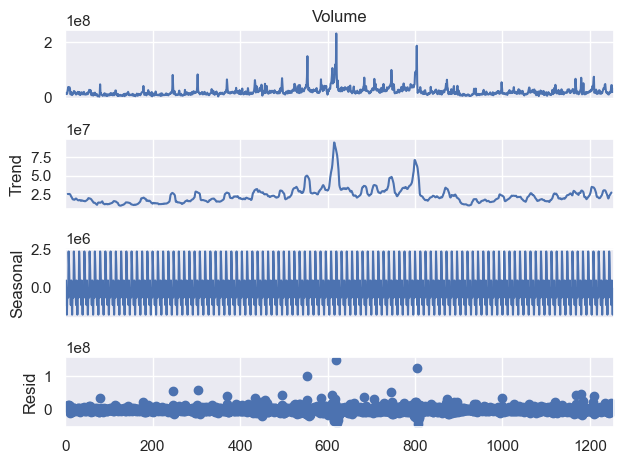

In [59]:
# Decomposition method
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_date['Volume'], period=12)
decomposition.plot()
plt.show()

In [60]:
df_date['Date'] = pd.to_datetime(df_date['Date'])

In [62]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1256 non-null   datetime64[ns]
 1   Volume      1256 non-null   int64         
 2   Time_Stamp  1256 non-null   datetime64[ns]
 3   Open        1256 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(1)
memory usage: 39.4 KB


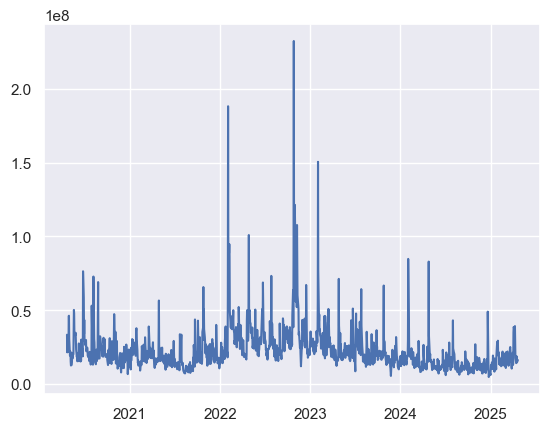

In [63]:
plt.plot(df_date['Date'], df_date['Volume'])
plt.show()

In [64]:
df_date['Volume'].describe()

count    1.256000e+03
mean     2.293379e+07
std      1.574444e+07
min      4.726056e+06
25%      1.444080e+07
50%      1.913176e+07
75%      2.669698e+07
max      2.323166e+08
Name: Volume, dtype: float64

In [69]:
# another method of importing dataset
df_final = pd.read_csv(r"C:\Users\shubh\OneDrive\Desktop\GITHUB\BANG2025\Machine Learning Projects\Stock Price Prediction\HistoricalData_1745308991181.csv", parse_dates=True, index_col=0)
df_final.head()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2025-04-21,$484.66,16165980,$491.325,$493.50,$479.80
2025-04-17,$501.48,14593510,$505.25,$507.30,$498.0133
2025-04-16,$502.31,18735080,$508.51,$513.37,$495.63
2025-04-15,$521.52,15558660,$532.105,$537.94,$517.50
2025-04-14,$531.48,14130930,$556.175,$557.77,$528.28


In [70]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2025-04-21 to 2020-04-22
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Close/Last  1256 non-null   object
 1   Volume      1256 non-null   int64 
 2   Open        1256 non-null   object
 3   High        1256 non-null   object
 4   Low         1256 non-null   object
dtypes: int64(1), object(4)
memory usage: 58.9+ KB


In [78]:
for col in df_final.columns:
    if col != "Volume":
        df_final[col] = pd.to_numeric(df_final[col].str.replace(r'[^\d.]', '', regex=True), errors='coerce')

In [79]:
print(df_final.info())  # Verify datatype changes

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2025-04-21 to 2020-04-22
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Close/Last  1256 non-null   float64
 1   Volume      1256 non-null   int64  
 2   Open        1256 non-null   float64
 3   High        1256 non-null   float64
 4   Low         1256 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 58.9 KB
None


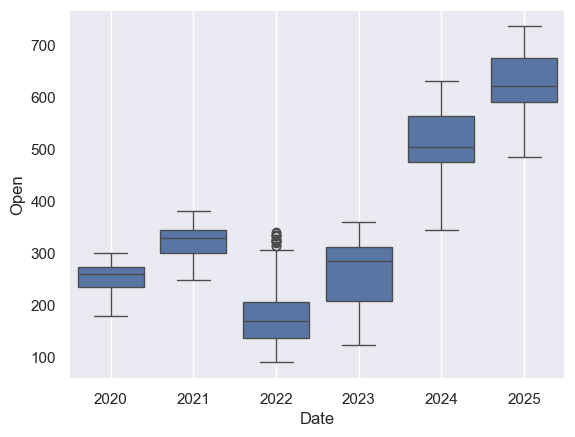

In [80]:
sns.boxplot(x=df_final.index.year, y= df_final['Open'])
plt.grid()

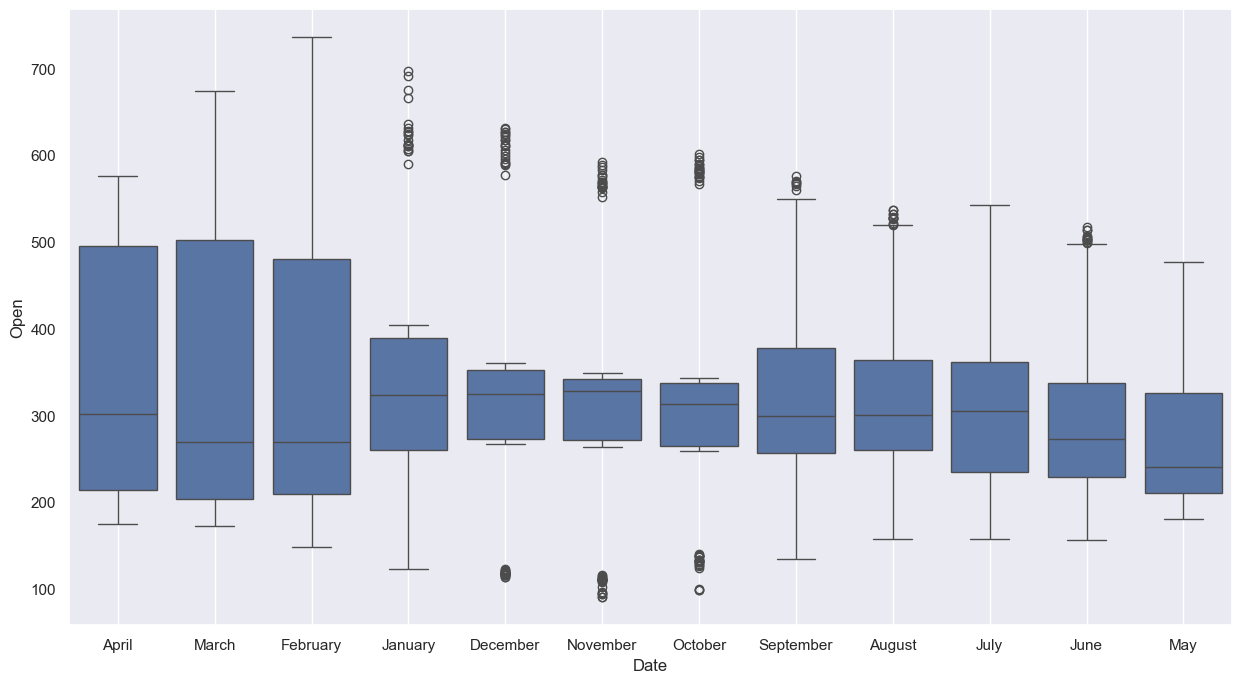

In [81]:
from pylab import rcParams
rcParams['figure.figsize']=15,8
sns.boxplot(x=df_final.index.month_name(), y= df_final['Open'])
plt.grid()

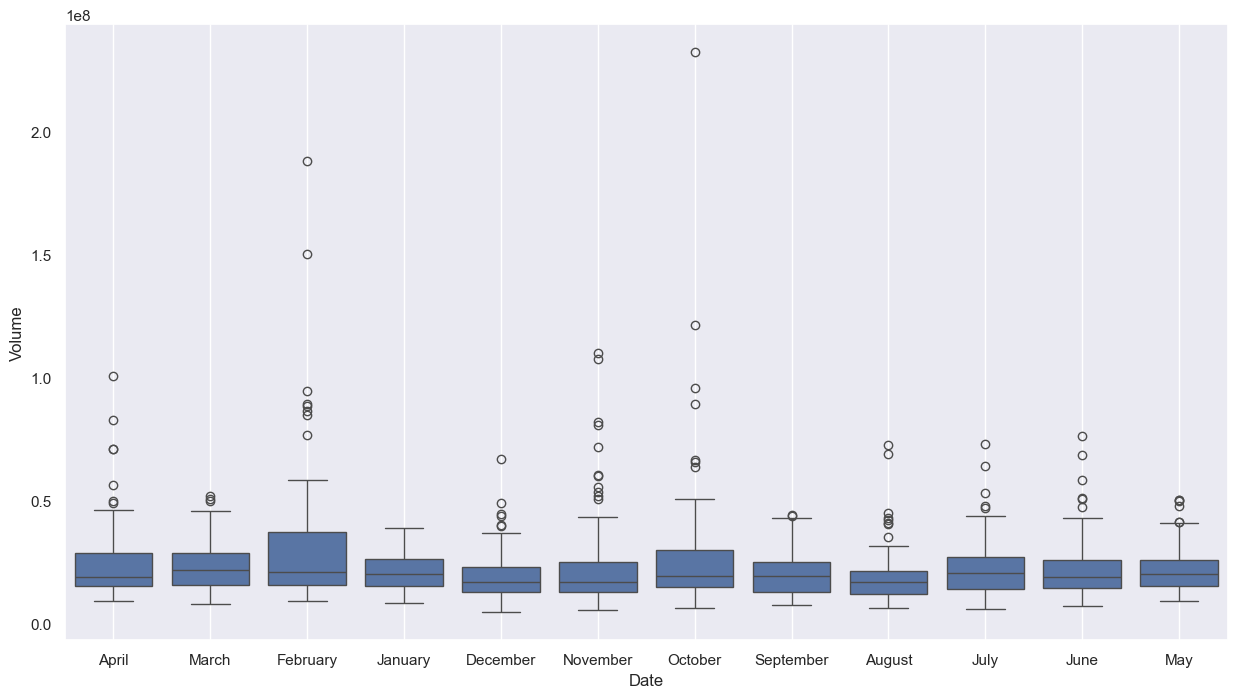

In [82]:
from pylab import rcParams
rcParams['figure.figsize']=15,8
sns.boxplot(x=df_final.index.month_name(), y= df_final['Volume'])
plt.grid()

In [83]:
df_final['Month'] = df_final.index.month
df_final['Year'] = df_final.index.year

In [84]:
df_final

,Close/Last,Volume,Open,High,Low,Month,Year
Date,,,,,,,
2025-04-21,484.66,16165980,491.325,493.50,479.8000,4,2025
2025-04-17,501.48,14593510,505.250,507.30,498.0133,4,2025
2025-04-16,502.31,18735080,508.510,513.37,495.6300,4,2025
2025-04-15,521.52,15558660,532.105,537.94,517.5000,4,2025
2025-04-14,531.48,14130930,556.175,557.77,528.2800,4,2025
...,...,...,...,...,...,...,...
2020-04-28,182.91,21730990,188.660,189.20,182.5600,4,2020
2020-04-27,187.50,29197750,192.657,193.75,187.4100,4,2020
2020-04-24,190.07,28868530,183.230,190.41,180.8250,4,2020


In [85]:
df['Time_Stamp'] = pd.to_datetime(df['Date'])
df_final_model = df.set_index('Time_Stamp')
df_final_model

,Date,Close/Last,Volume,Open,High,Low
Time_Stamp,,,,,,
2025-04-21,04/21/2025,$484.66,16165980,$491.325,$493.50,$479.80
2025-04-17,04/17/2025,$501.48,14593510,$505.25,$507.30,$498.0133
2025-04-16,04/16/2025,$502.31,18735080,$508.51,$513.37,$495.63
2025-04-15,04/15/2025,$521.52,15558660,$532.105,$537.94,$517.50
2025-04-14,04/14/2025,$531.48,14130930,$556.175,$557.77,$528.28
...,...,...,...,...,...,...
2020-04-28,04/28/2020,$182.91,21730990,$188.66,$189.20,$182.56
2020-04-27,04/27/2020,$187.50,29197750,$192.657,$193.75,$187.41
2020-04-24,04/24/2020,$190.07,28868530,$183.23,$190.41,$180.825


In [86]:
df_final_model['Date'] = pd.to_datetime(df_final_model['Date'])
df_final_model.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2025-04-21 to 2020-04-22
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1256 non-null   datetime64[ns]
 1   Close/Last  1256 non-null   object        
 2   Volume      1256 non-null   int64         
 3   Open        1256 non-null   object        
 4   High        1256 non-null   object        
 5   Low         1256 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 68.7+ KB


In [87]:
df_final_model.head()

,Date,Close/Last,Volume,Open,High,Low
Time_Stamp,,,,,,
2025-04-21,2025-04-21,$484.66,16165980,$491.325,$493.50,$479.80
2025-04-17,2025-04-17,$501.48,14593510,$505.25,$507.30,$498.0133
2025-04-16,2025-04-16,$502.31,18735080,$508.51,$513.37,$495.63
2025-04-15,2025-04-15,$521.52,15558660,$532.105,$537.94,$517.50
2025-04-14,2025-04-14,$531.48,14130930,$556.175,$557.77,$528.28


In [88]:
df_final_model.tail()

,Date,Close/Last,Volume,Open,High,Low
Time_Stamp,,,,,,
2020-04-28,2020-04-28,$182.91,21730990,$188.66,$189.20,$182.56
2020-04-27,2020-04-27,$187.50,29197750,$192.657,$193.75,$187.41
2020-04-24,2020-04-24,$190.07,28868530,$183.23,$190.41,$180.825
2020-04-23,2020-04-23,$185.13,21426600,$184.08,$187.05,$183.15
2020-04-22,2020-04-22,$182.28,33369930,$178.45,$184.78,$178.14


In [89]:
len(df_final_model)

1256

In [91]:
# very important point
train = df_final_model[pd.to_datetime(df_final_model['Date']) < pd.to_datetime('2024-06-05')]
train.shape

(1037, 6)

In [92]:
test = df_final_model[pd.to_datetime(df_final_model['Date']) >= pd.to_datetime('2024-06-05')]
test.shape

(219, 6)

In [93]:
train_final = train[['Volume']]
test_final = test[['Volume']]

In [94]:
train_final.head()

,Volume
Time_Stamp,
2024-06-04,7088718
2024-06-03,11279390
2024-05-31,16919810
2024-05-30,10735230
2024-05-29,9226218


In [95]:
train_final.tail()

,Volume
Time_Stamp,
2020-04-28,21730990
2020-04-27,29197750
2020-04-24,28868530
2020-04-23,21426600
2020-04-22,33369930


In [96]:
test_final.head()

,Volume
Time_Stamp,
2025-04-21,16165980
2025-04-17,14593510
2025-04-16,18735080
2025-04-15,15558660
2025-04-14,14130930


In [97]:
test_final.tail()

,Volume
Time_Stamp,
2024-06-11,9673715
2024-06-10,11236920
2024-06-07,9380745
2024-06-06,10667340
2024-06-05,15690480


# Automation method - Facebook Prophet model

In [98]:
!pip install prophet

   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/13.3 MB 6.3 MB/s eta 0:00:02
   --- ------------------------------------ 1.3/13.3 MB 4.0 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/13.3 MB 2.8 MB/s eta 0:00:05
   ------- -------------------------------- 2.6/13.3 MB 3.0 MB/s eta 0:00:04
   ----------- ---------------------------- 3.9/13.3 MB 3.6 MB/s eta 0:00:03
   -------------- ------------------------- 4.7/13.3 MB 3.7 MB/s eta 0:00:03
   --------------- ------------------------ 5.2/13.3 MB 3.7 MB/s eta 0:00:03
   ------------------ --------------------- 6.3/13.3 MB 3.7 MB/s eta 0:00:02
   -------------------- ------------------- 6.8/13.3 MB 3.6 MB/s eta 0:00:02
   ----------------------- ---------------- 7.9/13.3 MB 3.7 MB/s eta 0:00:02
   ------------------------- -------------- 8.7/13.3 MB 3.8 MB/s eta 0:00:02
   ---------------------------- ----------- 9.4/13.3 MB 3.8 MB/s eta 0:00:02
   ---

In [100]:
import prophet

In [101]:
from prophet import Prophet

In [102]:
dir(prophet)

['Path',
 'Prophet',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'about',
 'diagnostics',
 'f',
 'forecaster',
 'here',
 'make_holidays',
 'models',
 'plot']

In [103]:
model = Prophet()

In [104]:
df_final_model.columns

Index(['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low'], dtype='object')

In [105]:
df_final_model_1 = df_final_model[['Date','Volume']]
df_final_model_1

,Date,Volume
Time_Stamp,,
2025-04-21,2025-04-21,16165980
2025-04-17,2025-04-17,14593510
2025-04-16,2025-04-16,18735080
2025-04-15,2025-04-15,15558660
2025-04-14,2025-04-14,14130930
...,...,...
2020-04-28,2020-04-28,21730990
2020-04-27,2020-04-27,29197750
2020-04-24,2020-04-24,28868530


In [106]:
df_final_model_1.columns = ['ds','y']

In [107]:
df_final_model_1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2025-04-21 to 2020-04-22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1256 non-null   datetime64[ns]
 1   y       1256 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 29.4 KB


In [108]:
model.fit(df_final_model_1)

16:53:19 - cmdstanpy - INFO - Chain [1] start processing
16:53:20 - cmdstanpy - INFO - Chain [1] done processing


In [109]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [110]:
df_final_model_1.tail()

,ds,y
Time_Stamp,,
2020-04-28,2020-04-28,21730990
2020-04-27,2020-04-27,29197750
2020-04-24,2020-04-24,28868530
2020-04-23,2020-04-23,21426600
2020-04-22,2020-04-22,33369930


In [111]:
future_dates = model.make_future_dataframe(periods=1000)
future_dates.tail()

,ds
2251,2028-01-12
2252,2028-01-13
2253,2028-01-14
2254,2028-01-15
2255,2028-01-16


In [112]:
predict = model.predict(future_dates)
predict

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-04-22,2.810497e+07,1.567506e+07,4.711308e+07,2.810497e+07,2.810497e+07,3.550684e+06,3.550684e+06,3.550684e+06,-1.074277e+06,-1.074277e+06,-1.074277e+06,4.624960e+06,4.624960e+06,4.624960e+06,0.0,0.0,0.0,3.165565e+07
1,2020-04-23,2.807650e+07,1.656860e+07,5.050481e+07,2.807650e+07,2.807650e+07,5.974366e+06,5.974366e+06,5.974366e+06,9.019941e+05,9.019941e+05,9.019941e+05,5.072372e+06,5.072372e+06,5.072372e+06,0.0,0.0,0.0,3.405087e+07
2,2020-04-24,2.804804e+07,1.772370e+07,5.015081e+07,2.804804e+07,2.804804e+07,5.608694e+06,5.608694e+06,5.608694e+06,1.646241e+05,1.646241e+05,1.646241e+05,5.444070e+06,5.444070e+06,5.444070e+06,0.0,0.0,0.0,3.365673e+07
3,2020-04-27,2.796264e+07,1.509897e+07,4.754190e+07,2.796264e+07,2.796264e+07,3.567619e+06,3.567619e+06,3.567619e+06,-2.471823e+06,-2.471823e+06,-2.471823e+06,6.039442e+06,6.039442e+06,6.039442e+06,0.0,0.0,0.0,3.153026e+07
4,2020-04-28,2.793418e+07,1.480573e+07,4.780577e+07,2.793418e+07,2.793418e+07,3.293982e+06,3.293982e+06,3.293982e+06,-2.758138e+06,-2.758138e+06,-2.758138e+06,6.052120e+06,6.052120e+06,6.052120e+06,0.0,0.0,0.0,3.122816e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2251,2028-01-12,8.698604e+06,-3.096647e+07,3.615063e+07,-1.921052e+07,3.783227e+07,-6.860118e+06,-6.860118e+06,-6.860118e+06,-1.074277e+06,-1.074277e+06,-1.074277e+06,-5.785841e+06,-5.785841e+06,-5.785841e+06,0.0,0.0,0.0,1.838486e+06
2252,2028-01-13,8.692961e+06,-2.776036e+07,3.766910e+07,-1.922750e+07,3.787596e+07,-4.222982e+06,-4.222982e+06,-4.222982e+06,9.019941e+05,9.019941e+05,9.019941e+05,-5.124976e+06,-5.124976e+06,-5.124976e+06,0.0,0.0,0.0,4.469979e+06
2253,2028-01-14,8.687319e+06,-2.980097e+07,3.973266e+07,-1.924448e+07,3.791966e+07,-4.209569e+06,-4.209569e+06,-4.209569e+06,1.646241e+05,1.646241e+05,1.646241e+05,-4.374193e+06,-4.374193e+06,-4.374193e+06,0.0,0.0,0.0,4.477750e+06
2254,2028-01-15,8.681676e+06,-2.629777e+07,4.298832e+07,-1.926146e+07,3.796336e+07,-9.210811e+05,-9.210811e+05,-9.210811e+05,2.618810e+06,2.618810e+06,2.618810e+06,-3.539891e+06,-3.539891e+06,-3.539891e+06,0.0,0.0,0.0,7.760595e+06


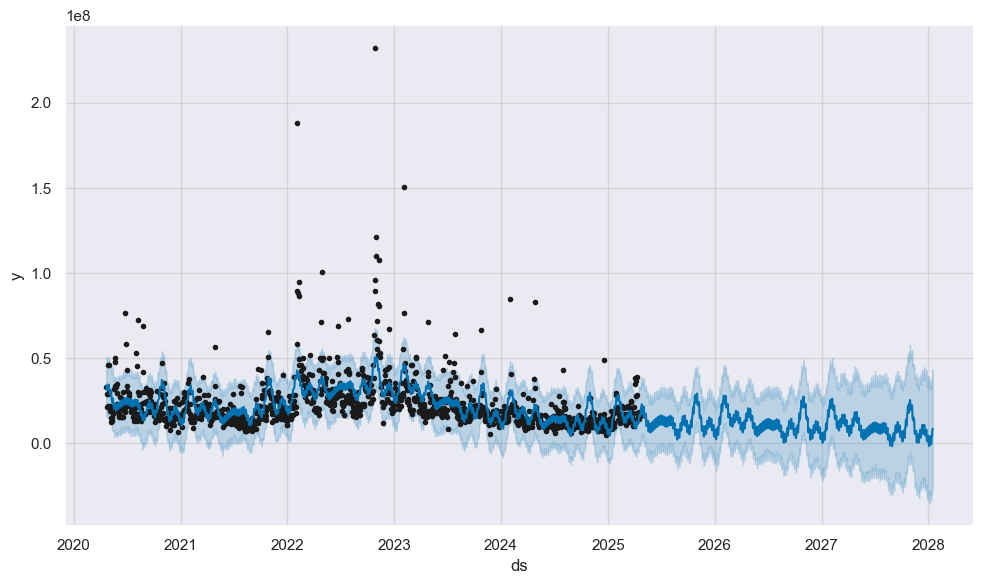

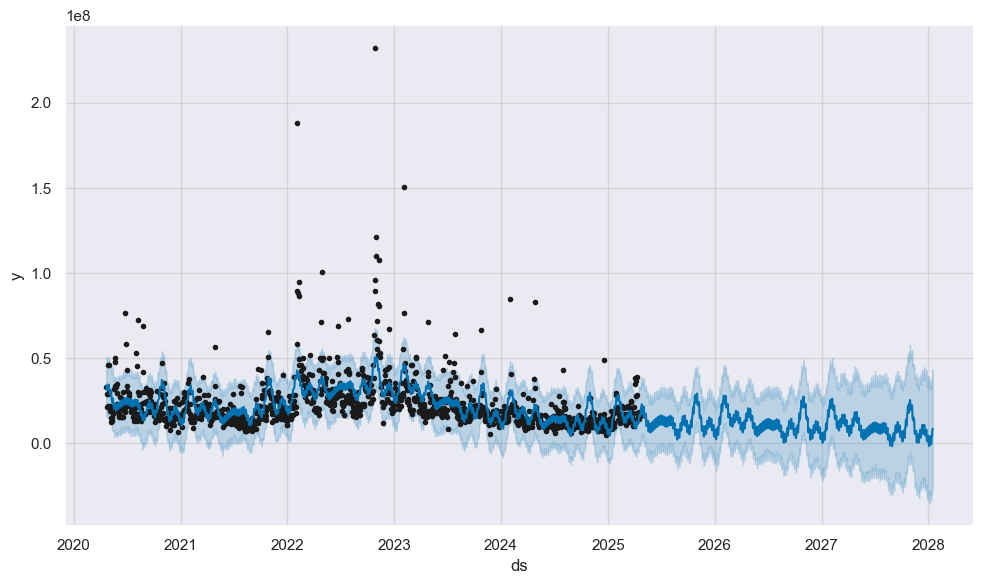

In [113]:
model.plot(predict)

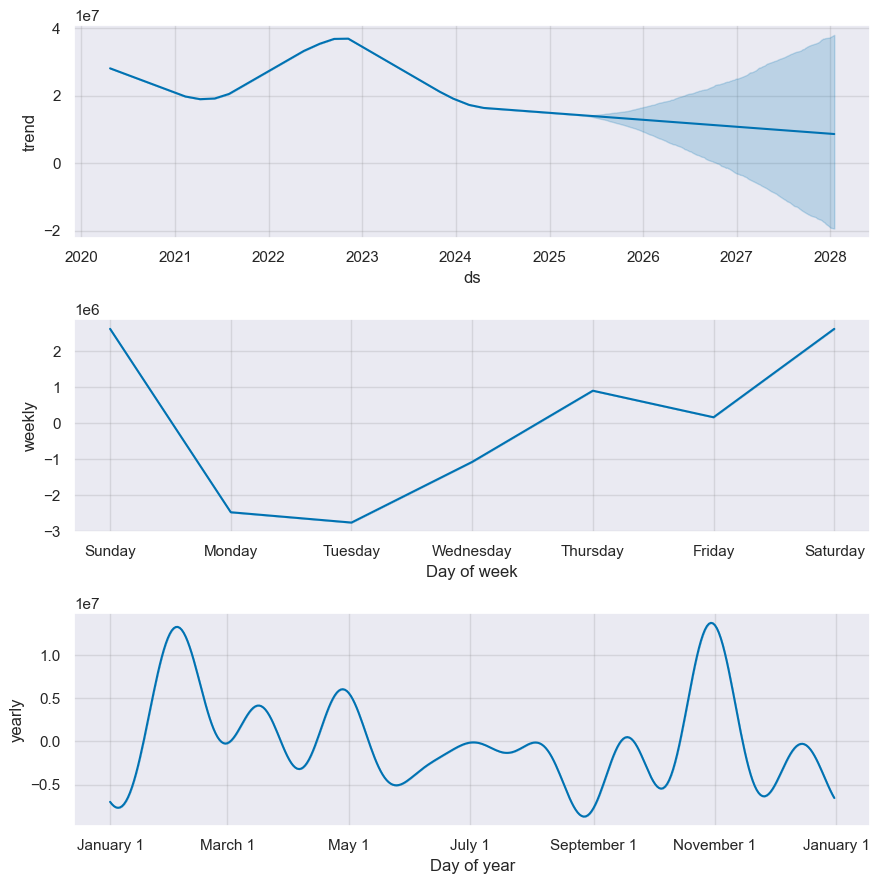

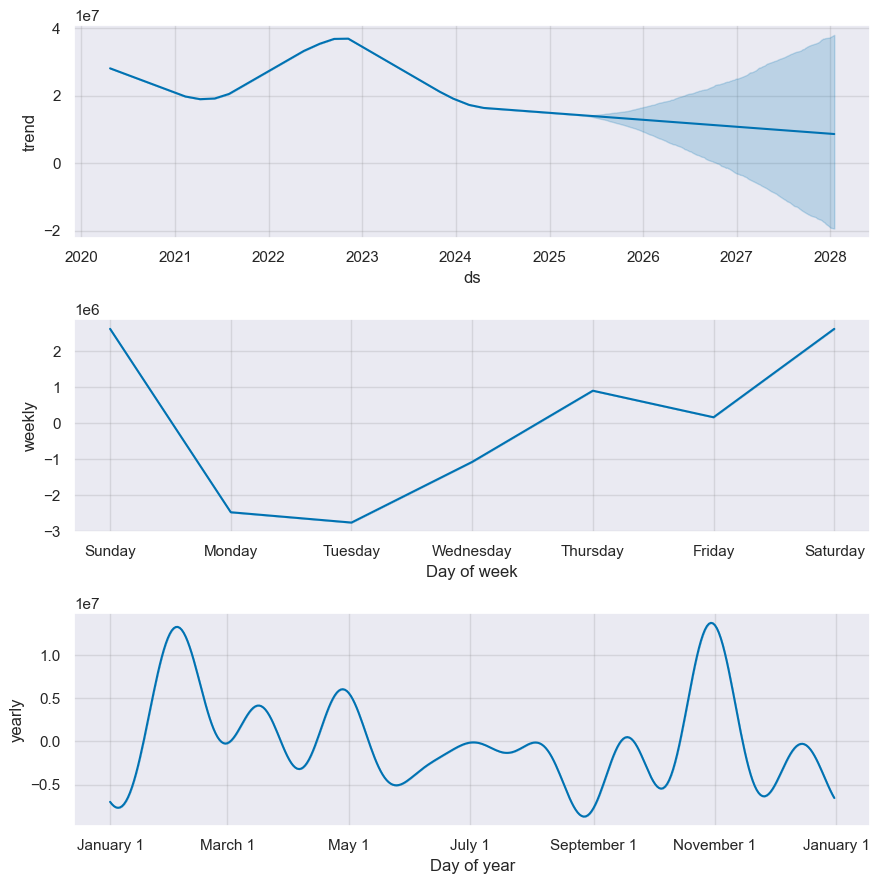

In [114]:
model.plot_components(predict)

In [122]:
predict.to_csv("stock_predictions.csv", index=False)

In [127]:
predict.to_csv(r"C:\Users\shubh\OneDrive\Desktop\GITHUB\BANG2025\Machine Learning Projects\StockpricePredicted.csv", index=False)

In [128]:
predict.to_csv("stock_predictions.csv", index=False, encoding="utf-8")

In [129]:
predict.to_csv(r"C:\Users\shubh\OneDrive\Desktop\GITHUB\BANG2025\Machine Learning Projects\StockpricePredicted.csv", index=False)